<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports

In [5]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


# Globals


In [6]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"

DATASET_FILE_ID = "1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI"
DATASET_ZIP_PATH = "/content/RRDataset_subset.zip"

# Training hyperparameters for the first baseline.
EPOCHS = 10
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Setup repository



In [7]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
Cloning into '/content/REPO'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 125 (delta 64), reused 55 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (125/125), 678.41 KiB | 10.44 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/REPO


# Install dependencies

In [8]:
# Install project dependencies.
!pip install -q -r requirements.txt


# Utils

In [9]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


In [10]:
def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')

In [11]:
def show_evaluation_outputs(output_dir):
    """
    Show evaluation metrics and confusion matrices saved by evaluate_RGB.py.
    """

    output_dir = Path(output_dir)
    metrics_path = output_dir / "metrics.json"

    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return

    # Load metrics saved by evaluate_RGB.py.
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    # Convert metrics dictionary into a readable table.
    rows = []

    for metric_name, value in metrics.items():
        if isinstance(value, dict):
            for sub_metric_name, sub_value in value.items():
                rows.append({
                    "Metric": metric_name,
                    "Group": sub_metric_name,
                    "Value": sub_value,
                })
        else:
            rows.append({
                "Metric": metric_name,
                "Group": "-",
                "Value": value,
            })

    metrics_df = pd.DataFrame(rows)

    # Format numeric values to 4 decimals.
    if not metrics_df.empty:
        metrics_df["Value"] = metrics_df["Value"].apply(
            lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
        )

    print("Evaluation metrics")
    display(metrics_df)

    # Show saved confusion matrices as images.
    fake_cm_path = output_dir / "confusion_fake.png"
    transform_cm_path = output_dir / "confusion_transform.png"

    if fake_cm_path.exists():
        print("\nReal/Fake confusion matrix")
        display(Image(filename=str(fake_cm_path)))

    if transform_cm_path.exists():
        print("\nTransformation confusion matrix")
        display(Image(filename=str(transform_cm_path)))

    if not fake_cm_path.exists() and not transform_cm_path.exists():
        print("\nNo confusion matrix images found in this folder.")

# Data


In [12]:
train_df = show_csv_summary(TRAIN_CSV)

File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [13]:
val_df = show_csv_summary(VAL_CSV)

File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [14]:
test_df = show_csv_summary(TEST_CSV)

File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [15]:
# Download the dataset only if the zip file is not already available.
if not Path(DATASET_ZIP_PATH).exists():
    print("Dataset zip not found. Downloading it with gdown...")
    os.system(f'gdown --id "{DATASET_FILE_ID}" -O "{DATASET_ZIP_PATH}"')
else:
    print(f"Dataset zip already exists: {DATASET_ZIP_PATH}")

Dataset zip not found. Downloading it with gdown...


In [16]:
# Extract the dataset only if the extracted folder is not already available.
IMAGE_ROOT = Path(IMAGE_ROOT)
if not IMAGE_ROOT.exists():
    print("Extracted dataset folder not found. Extracting...")
    os.system(f'mkdir -p "{IMAGE_ROOT.parent}"')
    os.system(f'unzip -q "{DATASET_ZIP_PATH}" -d "{IMAGE_ROOT.parent}"')
else:
    print(f"Dataset already extracted: {IMAGE_ROOT}")

Extracted dataset folder not found. Extracting...


In [17]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)

Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# RGB baseline
## Train and Evaluation
### Single-task Real/Fake Baseline

In [18]:
# Train the real/fake single-task baseline.
!python src/train_RGB.py \
  --task fake \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_fake.pt

Selected task: fake
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 122MB/s]

Epoch 1/10
Training:  27% 18/66 [00:12<00:33,  1.42it/s]
Traceback (most recent call last):
object address  : 0x7ec7edfebca0
object refcount : 3
object type     : 0xa284e0
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr
^C


In [19]:
# Evaluate the real/fake single-task baseline.
!python src/evaluate_RGB.py \
  --task fake \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_fake.pt \
  --output_dir results/rgb_fake \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

object address  : 0x7e9928a8c3a0
object refcount : 3
object type     : 0xa284e0
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr
^C


In [20]:
show_evaluation_outputs("results/rgb_fake")

Metrics file not found: results/rgb_fake/metrics.json


### Single-task Transformation Baseline

In [21]:
# Train the transformation single-task baseline.
!python src/train_RGB.py \
  --task transform \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_transform.pt

Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 4, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2804, in <module>
    from torch import _meta_registrations
  File "/usr/local/lib/python3.12/dist-packages/torch/_meta_registrations.py", line 12, in <module>
    from torch._decomp import (
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/__init__.py", line 287, in <module>
    import torch._decomp.decompositions
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/decompositions.py", line 17, in <module>
    import torch._prims as prims
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 1141, in <module>
    maximum = _make_elementwise_binary_prim(
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 526, in _make_elementwise_binary_prim
    return _make_prim(
           ^^^^^^^^

In [22]:
# Evaluate the transformation single-task baseline.
!python src/evaluate_RGB.py \
  --task transform \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_transform.pt \
  --output_dir results/rgb_transform \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 7, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2229, in <module>
    from torch import _VF as _VF, functional as functional  # usort: skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/functional.py", line 8, in <module>
    import torch.nn.functional as F
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/__init__.py", line 8, in <module>
    from torch.nn.modules import *  # usort: skip # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/__init__.py", line 1, in <module>
    from .module import Module  # usort: skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 15, in <module>
    from torch._prims_common import DeviceLikeType
  File "<frozen impo

In [23]:
show_evaluation_outputs("results/rgb_transform")

Metrics file not found: results/rgb_transform/metrics.json


### Multi-task Baseline, Manual Weights 1.0 / 1.0

In [24]:
# Train the joint RGB multi-task baseline with weights 1 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_1_1.pt

Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 4, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2804, in <module>
  File "/usr/local/lib/python3.12/dist-packages/torch/_meta_registrations.py", line 12, in <module>
    from torch._decomp import (
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/__init__.py", line 287, in <module>
    import torch._decomp.decompositions
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/decompositions.py", line 17, in <module>
    import torch._prims as prims
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 885, in <module>
    ndtri = _make_elementwise_unary_prim(
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 511, in _make_elementwise_unary_prim
    return _make_prim(
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-package

In [25]:
# Evaluate the joint RGB multi-task baseline with weights 1 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_1.pt \
  --output_dir results/rgb_multitask_1_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 1756, in <module>
    @_deprecated(
     ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/typing_extensions.py", line 2997, in __call__
    import asyncio.coroutines
  File "/usr/lib/python3.12/asyncio/__init__.py", line 15, in <module>
    from .runners import *
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1322, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 1262, in _find_spec
  File "<frozen importlib._bootstrap

In [26]:
show_evaluation_outputs("results/rgb_multitask_1_1")

Metrics file not found: results/rgb_multitask_1_1/metrics.json


### Multi-task Baseline, Manual Weights 1.0 / 2.0

In [27]:
# Train the joint RGB multi-task baseline with weights 1 2.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 2.0 \
  --checkpoint_name best_rgb_multitask_1_2.pt

Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/__init__.py", line 287, in <module>
    import torch._decomp.decompositions
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/decompositions.py", line 17, in <module>
    import torch._prims as prims
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 641, in <module>
    bessel_i1e = _make_elementwise_unary_prim(
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 511, in _make_elementwise_unary_prim
    return _make_prim(
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist

In [28]:
# Evaluate the joint RGB multi-task baseline with weights 1 2.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_2.pt \
  --output_dir results/rgb_multitask_1_2 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/intrinsic/quantized/__init__.py", line 3, in <module>
    from torch.nn.intrinsic.quantized import dynamic, modules  # noqa: F401
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/intrinsic/quantized/dynamic/__init__.py", line 1, in <module>
    from torch.nn.intrinsic.quantized.dynamic.modules import *  # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/intrinsic/quantized/dynamic/modu

In [29]:
show_evaluation_outputs("results/rgb_multitask_1_2")

Metrics file not found: results/rgb_multitask_1_2/metrics.json


### Multi-task Baseline, Manual Weights 2.0 / 1.0

In [30]:
# Train the joint RGB multi-task baseline with weights 2 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 2.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_2_1.pt

Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 4, in <module>
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2229, in <module>
    from torch import _VF as _VF, functional as functional  # usort: skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/functional.py", line 8, in <module>
    import torch.nn.functional as F
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/__init__.py", line 9, in <module>
    from torch.nn import (
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/attention/__init__.py", line 9, in <module>
    import torch.backends.cuda
  File "/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py", line 124, in <module>
    from torch.backends import (
  File "/usr/local/lib/python3.12/dist-packages/torch/backends/opt_einsum/__init__.py", line 12, in <module>
    import opt_einsum as _opt_einsum  # type: ignore[import]
  

In [31]:
# Evaluate the joint RGB multi-task baseline with weights 2 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_2_1.pt \
  --output_dir results/rgb_multitask_2_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "/content/REPO/src/evaluate_RGB.py", line 7, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2273, in <module>
    from torch import (
  File "/usr/local/lib/python3.12/dist-packages/torch/optim/__init__.py", line 10, in <module>
    from torch.optim._adafactor import Adafactor as Adafactor
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1091, in get_code
object address  : 0x7e71715d5900
object refcount : 3
object type     : 0xa284e0
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr
^C


In [32]:
show_evaluation_outputs("results/rgb_multitask_2_1")

Metrics file not found: results/rgb_multitask_2_1/metrics.json


### Multi-task Baseline, Learned Uncertainty Weighting

In [33]:
# Train the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/train_RGB.py \
  --task multitask \
  --loss_weighting learned \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_multitask_learned_weights.pt

Traceback (most recent call last):
  File "/content/REPO/src/train_RGB.py", line 4, in <module>
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2804, in <module>
    from torch import _meta_registrations
  File "/usr/local/lib/python3.12/dist-packages/torch/_meta_registrations.py", line 12, in <module>
    from torch._decomp import (
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/__init__.py", line 287, in <module>
    import torch._decomp.decompositions
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/decompositions.py", line 17, in <module>
    import torch._prims as prims
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 1086, in <module>
    gt = _make_elementwise_binary_prim(
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 526, in _make_elementwise_binary_prim
    return _make_prim(
           ^^^^^^^^^^^
  File "/usr/local/lib/

In [34]:
# Evaluate the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_learned_weights.pt \
  --output_dir results/rgb_multitask_learned_weights \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/replicate.py", line 21, in <module>
    def _is_script_module(module: Module) -> TypeIs["ScriptModule"]:
                                             ~~~~~~^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/typing.py", line 395, in inner
    return _caches[func](*args, **kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/typing.py", line 517, in __getitem__
    return self._getitem(self, parameters)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/typing_extensions.py

In [35]:
show_evaluation_outputs("results/rgb_multitask_learned_weights")

Metrics file not found: results/rgb_multitask_learned_weights/metrics.json


## Results Comparison and Ablation Study

In [36]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}

rows = []

for model_name, metrics_path in results.items():
    metrics_path = Path(metrics_path)

    if not metrics_path.exists():
        print(f"Missing file: {metrics_path}")
        continue

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    rows.append({
        "model": model_name,
        "fake_accuracy": metrics.get("fake_accuracy"),
        "fake_f1_macro": metrics.get("fake_f1_macro"),
        "transform_accuracy": metrics.get("transform_accuracy"),
        "transform_f1_macro": metrics.get("transform_f1_macro"),
        "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
        "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
        "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.sort_values(
    by=["fake_accuracy", "transform_accuracy"],
    ascending=False
)

Missing file: results/rgb_fake/metrics.json
Missing file: results/rgb_transform/metrics.json
Missing file: results/rgb_multitask_1_1/metrics.json
Missing file: results/rgb_multitask_1_2/metrics.json
Missing file: results/rgb_multitask_2_1/metrics.json
Missing file: results/rgb_multitask_learned_weights/metrics.json


KeyError: 'fake_accuracy'

In [ ]:
# Global Accuracy Comparison

plot_df = comparison_df.set_index("model")

plot_df[["fake_accuracy", "transform_accuracy"]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Global Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# Real/Fake Accuracy by Transformation Type
plot_df[[
    "fake_acc_original",
    "fake_acc_transfer",
    "fake_acc_redigital",
]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Real/Fake Accuracy by Transformation Type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#DEPTH

In [ ]:
!find /content -name "real_006970.jpg"

##Depth map generation

###first small debug

In [46]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV}\
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small \
  --max_images 5

Using device: cuda
Number of images to process: 5
Loading pretrained MiDaS model: MiDaS_small
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Loading weights:  None
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Generating depth maps: 100% 5/5 [00:00<00:00, 13897.63it/s]
Depth map generation completed.
Depth maps saved in: /content/depth_maps


###full depth map generation

In [48]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small

Using device: cuda
Number of images to process: 3000
Loading pretrained MiDaS model: MiDaS_small
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Loading weights:  None
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Generating depth maps: 100% 3000/3000 [00:36<00:00, 82.88it/s] 
Depth map generation completed.
Depth maps saved in: /content/depth_maps


##copy of depth maph in local so colab doesn't need to go on drive every time

In [50]:
DRIVE_DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"
LOCAL_DEPTH_ROOT = "/content/depth_maps"

!mkdir -p "{LOCAL_DEPTH_ROOT}"
!rsync -a --info=progress2 "{DRIVE_DEPTH_ROOT}/" "{LOCAL_DEPTH_ROOT}/"

DEPTH_ROOT = LOCAL_DEPTH_ROOT

print("Depth maps will be loaded from:", DEPTH_ROOT)

              0   0%    0.00kB/s    0:00:00 (xfr#0, to-chk=0/2560)  
Depth maps will be loaded from: /content/depth_maps


##First try with depth only

In [43]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting \
  --no_edge

Using device: cuda

Epoch 1/10
Training geometric: 100% 66/66 [01:54<00:00,  1.74s/it]
Validation geometric: 100% 15/15 [00:29<00:00,  1.99s/it]
Train: {'loss': 1.4201570750418164, 'fake_acc': 0.85, 'transform_acc': 0.41523809523809524, 'weight_fake': 1.0035468863718437, 'weight_transform': 0.9972273328087546}
Val:   {'loss': 1.0919746221436395, 'fake_acc': 0.9088888888888889, 'transform_acc': 0.5733333333333334}
Val score: 0.7411
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_depth_uncertainty.pt

Epoch 2/10
Training geometric: 100% 66/66 [01:53<00:00,  1.72s/it]
Validation geometric: 100% 15/15 [00:30<00:00,  2.02s/it]
Train: {'loss': 0.8327325288454691, 'fake_acc': 0.9738095238095238, 'transform_acc': 0.6004761904761905, 'weight_fake': 1.0114565094312031, 'weight_transform': 1.0002332230408986}
Val:   {'loss': 1.4934640726115969, 'fake_acc': 0.9066666666666666, 'transform_acc': 0.4866666666666667}
Val score: 0.6967
Learning rate: 0.000100
No improvement for 1/4 ep

The edge-consistency branch introduces additional geometric information, but also increases model complexity. This leads to mild overfitting and a small decrease in real/fake validation accuracy, although transformation classification slightly improves.
We should use only depth without edge

##Evaluate RGB+Depth no edge

In [51]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/depth_only \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9356
Fake F1 macro:        0.9355

Fake accuracy by transformation:
  original: 0.9267
  transfer: 0.9467
  redigital: 0.9333
Transform accuracy:   0.8022
Transform F1 macro:   0.8004

Saved results in:
results/depth_only


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9356
1,fake_f1_macro,-,0.9355
2,fake_accuracy_by_transform,original,0.9267
3,fake_accuracy_by_transform,transfer,0.9467
4,fake_accuracy_by_transform,redigital,0.9333
5,transform_accuracy,-,0.8022
6,transform_f1_macro,-,0.8004



Real/Fake confusion matrix


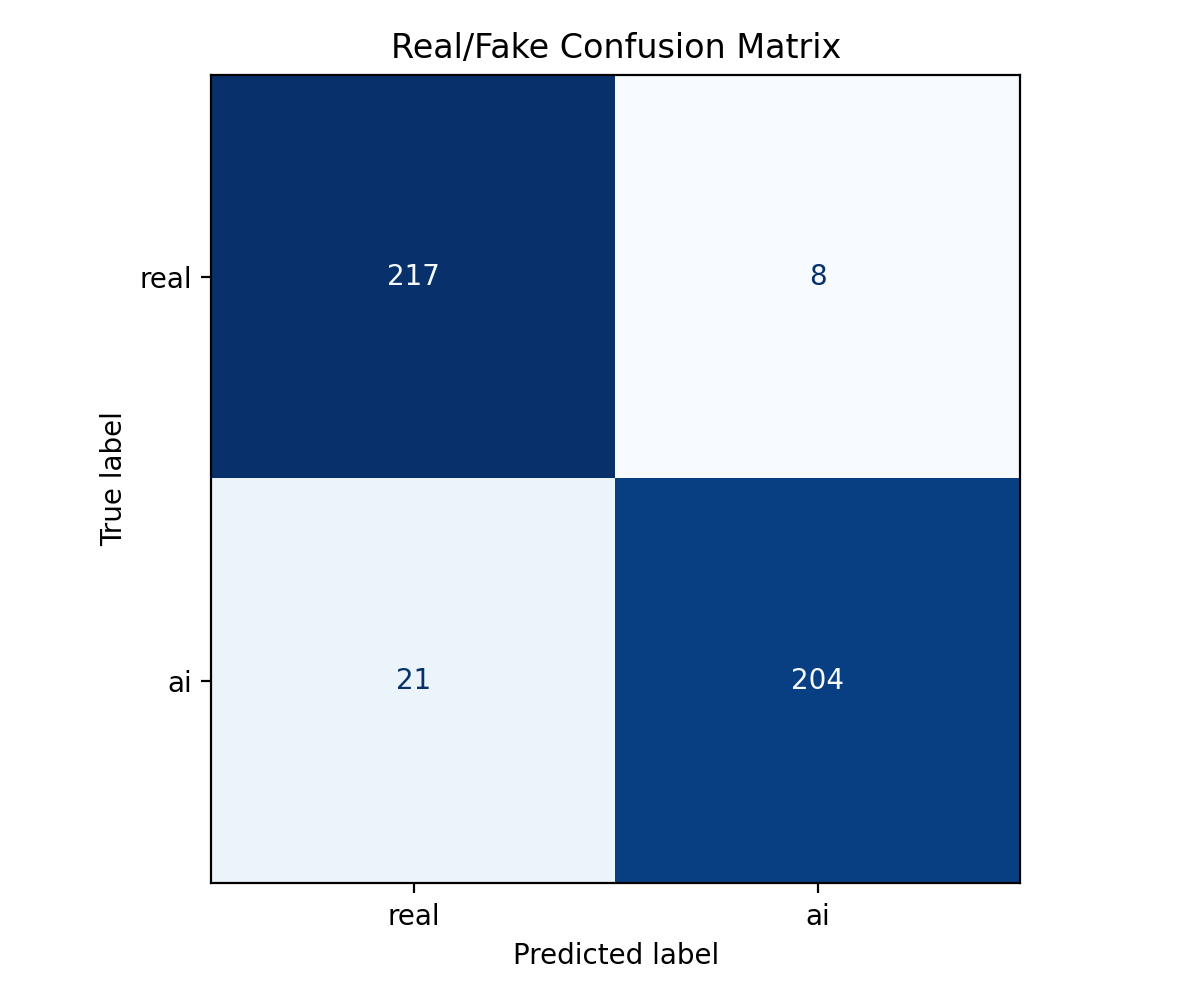


Transformation confusion matrix


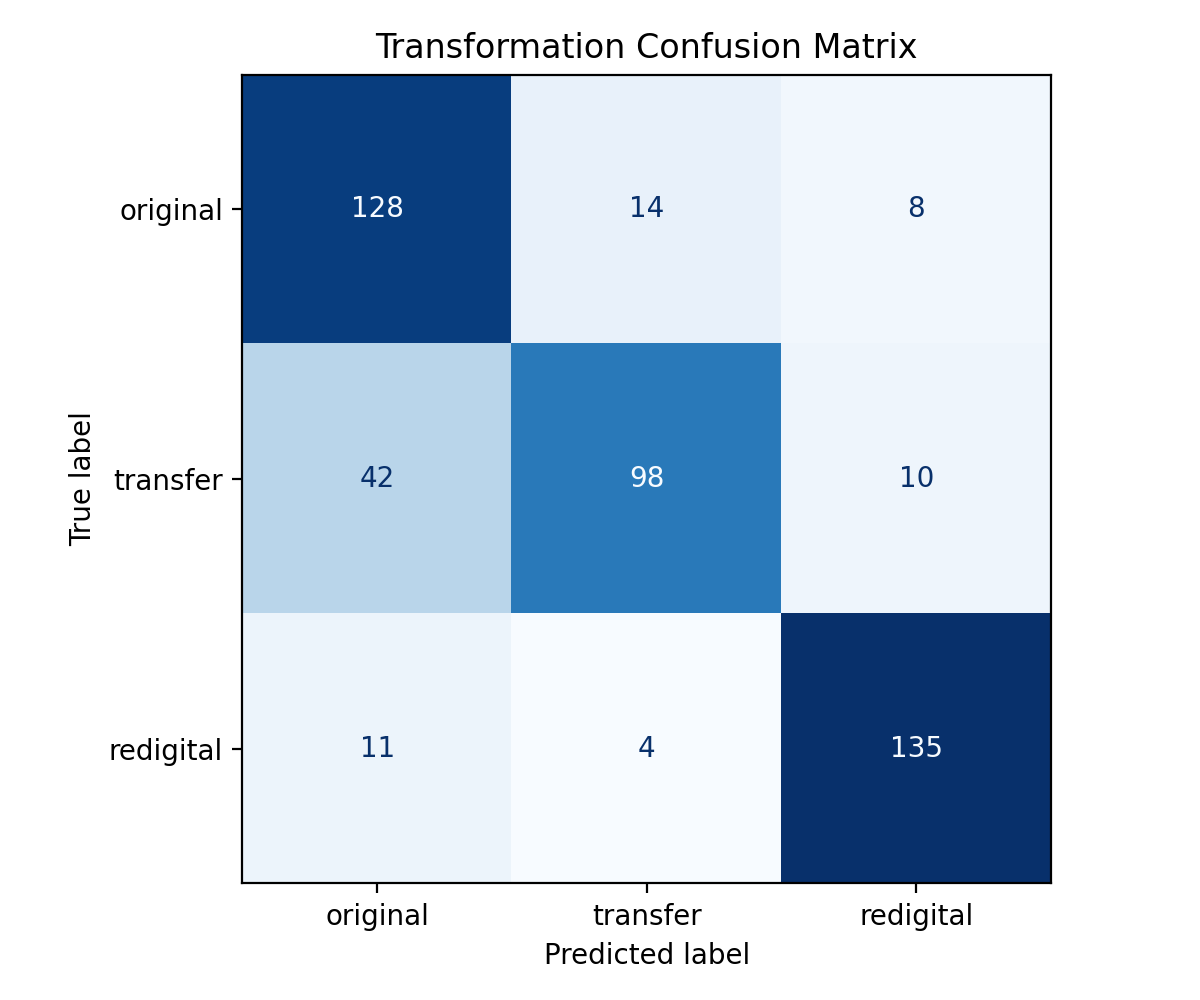

In [52]:
show_evaluation_outputs("results/depth_only")

##Second try with also edge consistency

In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_edge_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

##Evaluate RGB+Depth+edge

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/depth_edge \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

In [ ]:
show_evaluation_outputs("results/depth_edge")

##grad-cam

In [56]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/gradcam_depth_only_fake \
  --task fake \
  --target predicted \
  --max_images 12 \
  --image_size 224 \
  --no_edge

python3: can't open file '/content/REPO/src/gradCam_depth.py': [Errno 2] No such file or directory
